In [2]:
import jax 
import jax.numpy as jnp
from jax import random as jrd
import matplotlib.pyplot as plt
import nifty8.re as jft
from jax import jit
jax.config.update("jax_enable_x64", True)

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

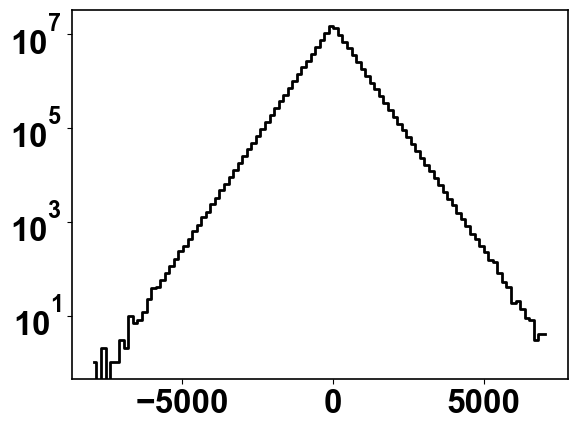

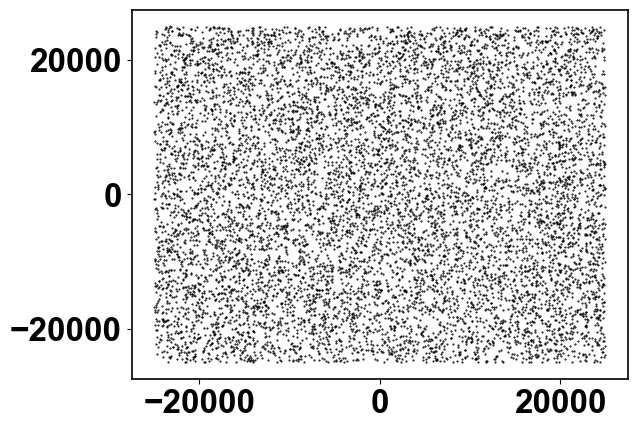

In [43]:
key = jrd.PRNGKey(99)
key, subkey = jrd.split(key)
z = jrd.laplace(subkey, shape=(100000000,))
z = z*450.
n, bins = jnp.histogram(z, bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
plt.yscale('log')
plt.show()
key, subkey = jrd.split(key)
x = jrd.uniform(subkey, shape=(100000000,), minval=-25000, maxval=25000)
key, subkey = jrd.split(key)
y = jrd.uniform(subkey, shape=(100000000,), minval=-25000, maxval=25000)
plt.scatter(x[::10000],y[::10000], s=1, color='black', marker='.')
plt.show()
r = jnp.sqrt(x**2 + y**2)
where = jnp.where(r<25000)
x = x[where]
y = y[where]
z = z[where]
r = r[where]

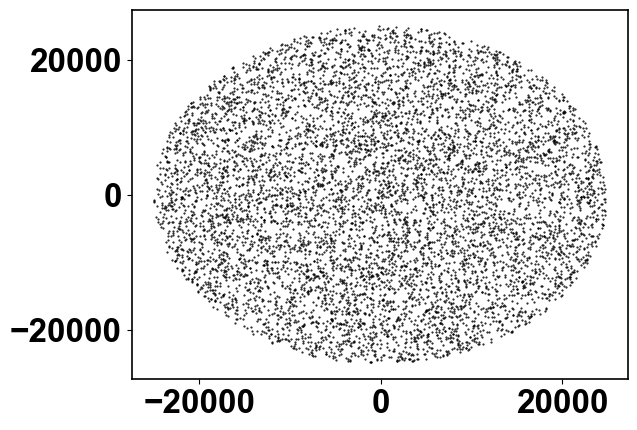

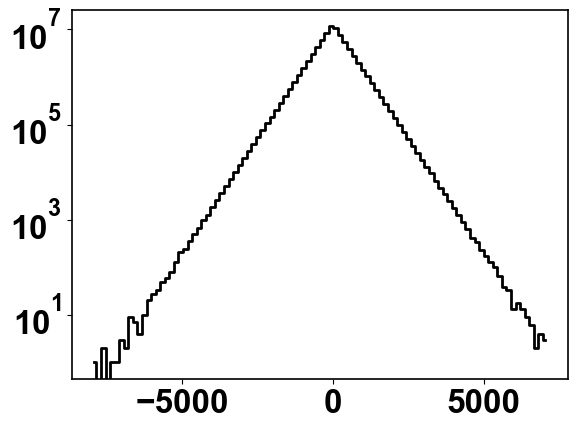

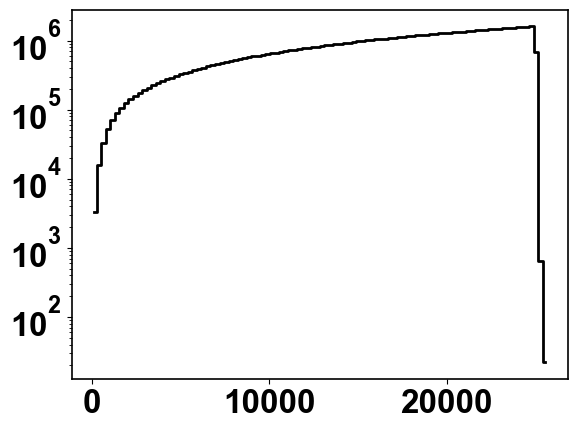

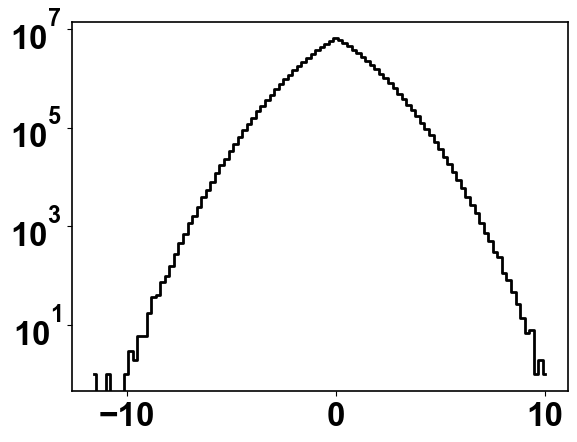

In [58]:
distance = jnp.sqrt(x**2 + y**2 + z**2)
b = jnp.arcsin(z/distance)
l = jnp.arctan2(y,x)
r = distance*jnp.cos(b)
plt.scatter((r*jnp.cos(l))[::10000], (r*jnp.sin(l))[::10000], s=1, color='black', marker='.')
plt.show()
n, bins = jnp.histogram(distance*jnp.sin(b), bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
plt.yscale('log')
plt.show()
parallax = 1000./distance
n, bins = jnp.histogram(distance, bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
plt.yscale('log')
plt.show()
# where = jnp.where(parallax>1)
# n, bins = jnp.histogram(parallax[where], bins=100)
# val = (bins[:-1] + bins[1:])/2
# plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
# plt.yscale('log')
# plt.show()
parallax_error = (0.01+0.4*distance/5000) * parallax * jrd.normal(subkey, shape=(len(distance),)) #distance dependent (0.3 statt term gaußisch)
n, bins = jnp.histogram(parallax_error/parallax, bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
plt.yscale('log')
plt.show()

78530622 78530622
61008636


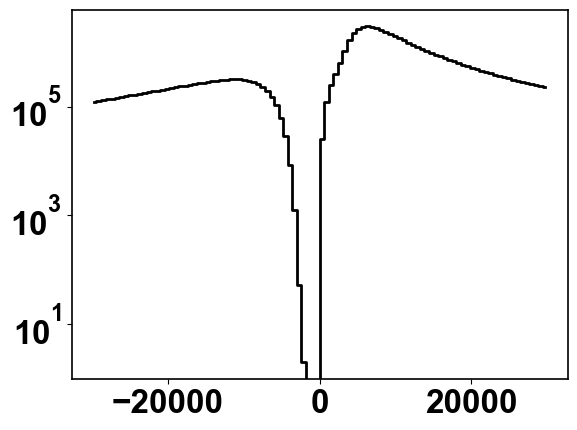

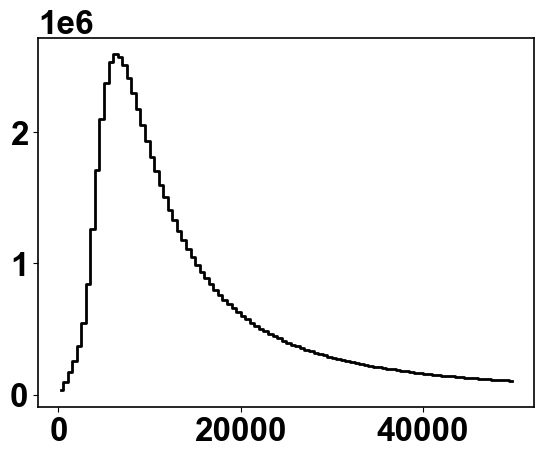

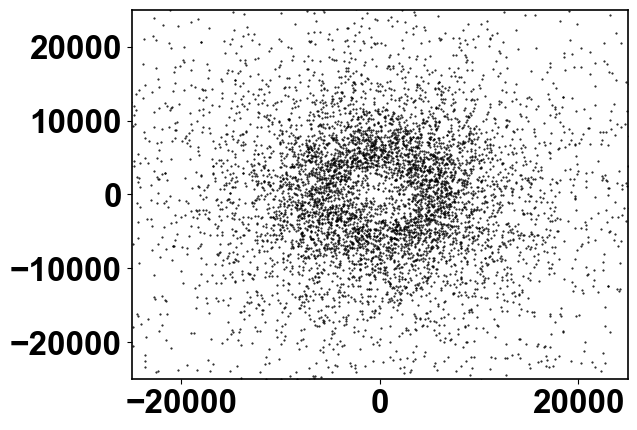

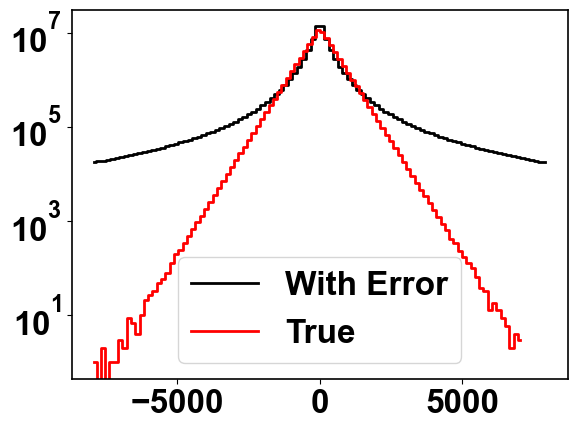

In [59]:
parallax_data = parallax + parallax_error
print(len(parallax_data), len(parallax))
distance_data = 1000./parallax_data
n, bins = jnp.histogram(distance_data[jnp.where(abs(distance_data)<=30000)], bins=100)
print(len(distance_data[jnp.where(abs(distance_data)<=30000)]))
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
plt.yscale('log')
plt.show()
r_data = abs(distance_data) * jnp.cos(b)
n, bins = jnp.histogram(r_data[jnp.where(r_data<50000)], bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='With Error')
plt.show()
plt.scatter((r_data*jnp.cos(l))[1000::10000], (r_data*jnp.sin(l))[1000::10000], s=1, color='black', marker='.')
plt.xlim(-25000,25000)
plt.ylim(-25000,25000)
plt.show()
z_data = distance_data * jnp.sin(b)
where = jnp.where(abs(z_data)<8000)
n, bins = jnp.histogram(z_data[where], bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='With Error')
n, bins = jnp.histogram(z, bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='red', drawstyle='steps-mid', label='True')
plt.yscale('log')
plt.legend()
plt.show()

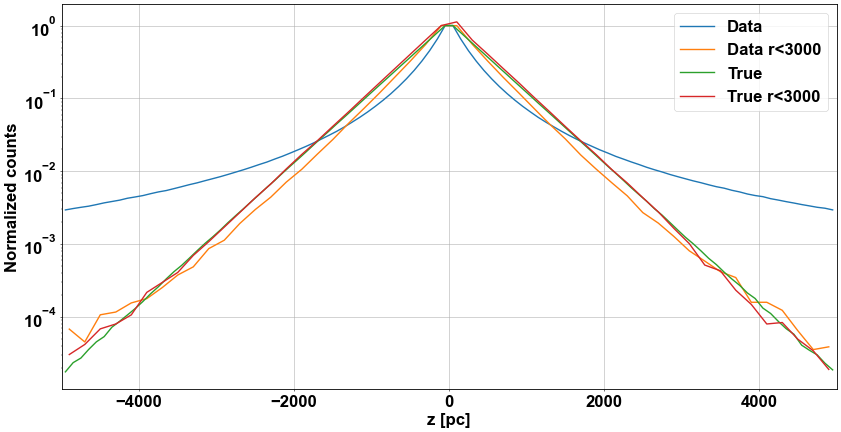

In [60]:
fig = plt.figure(figsize=(20,10))
n, bins = jnp.histogram(z_data, bins=100, range=(-5000, 5000))
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n/n[int(len(n)/2)-1], label='Data')
where_ = jnp.where(r_data<3000)
n_, bins_ = jnp.histogram(z_data[where_], bins=50, range=(-5000, 5000))
val_ = (bins_[:-1] + bins_[1:])/2
plt.plot(val_, n_/n_[int(len(n_)/2)-1], label='Data r<3000')
n__, bins__ = jnp.histogram(z, bins=100, range=(-5000, 5000))
val__ = (bins__[:-1] + bins__[1:])/2
plt.plot(val__, n__/n__[int(len(n__)/2)-1], label='True')
n___, bins___ = jnp.histogram(z[where][where_], bins=50, range=(-5000, 5000))
val___ = (bins___[:-1] + bins___[1:])/2
plt.plot(val___, n___/n___[int(len(n___)/2)-1], label='True r<3000')

plt.xlabel('z [pc]')
plt.ylabel('Normalized counts')
plt.yscale('log')
plt.xlim(-5000, 5000)
plt.legend()
plt.grid()
fig.set_dpi(50)
plt.show()

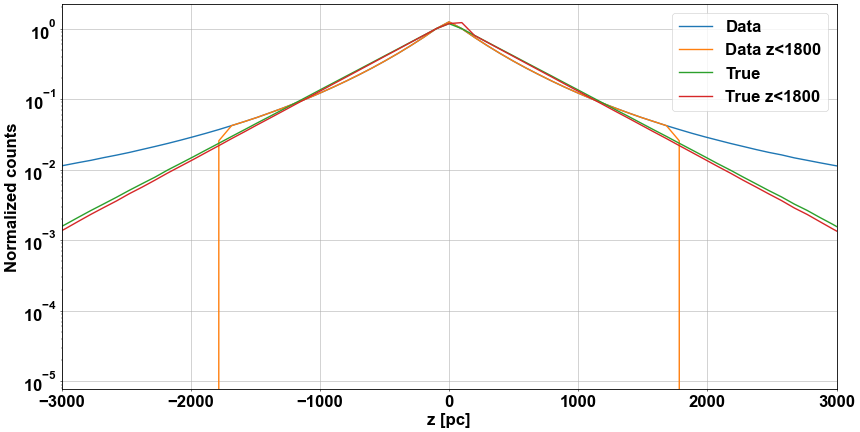

In [54]:
fig = plt.figure(figsize=(20,10))
n, bins = jnp.histogram(z_data, bins=101, range=(-5000, 5000))
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n/n[int(len(n)/2)-1], label='Data')
where__ = jnp.where(abs(z_data)<1800)
n_, bins_ = jnp.histogram(z_data[where__], bins=101, range=(-5000, 5000))
val_ = (bins_[:-1] + bins_[1:])/2
plt.plot(val_, n_/n_[int(len(n_)/2)-1], label='Data z<1800')
n__, bins__ = jnp.histogram(z, bins=101, range=(-5000, 5000))
val__ = (bins__[:-1] + bins__[1:])/2
plt.plot(val__, n__/n__[int(len(n__)/2)-1], label='True')
n___, bins___ = jnp.histogram(z[where][where__], bins=101, range=(-5000, 5000))
val___ = (bins___[:-1] + bins___[1:])/2
plt.plot(val___, n___/n___[int(len(n___)/2)-1], label='True z<1800')

plt.xlabel('z [pc]')
plt.ylabel('Normalized counts')
plt.yscale('log')
plt.xlim(-3000, 3000)
plt.legend()
plt.grid()
fig.set_dpi(50)
plt.show()

In [61]:
true_dist = jft.LaplacePrior(600, name='r', shape=(len(parallax_data[where_]),))
print(len(parallax_data[where_]))

1460101


In [63]:
class ForwardModel(jft.Model):
    def __init__(self):
        self.true_dist = true_dist
        super().__init__(init =  self.true_dist.init)

    @jit
    def __call__(self, x):
        z = self.true_dist(x)
        r = z/jnp.sin(b[where_])
        w = 1000./r
        return w

fwd = ForwardModel()
lh = jft.Gaussian(parallax_data[where_], lambda x: 1/parallax_error[where_]**2 * x).amend(fwd)
print(len(fwd(jft.random_like(jrd.PRNGKey(0), fwd.domain))))

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


1460101


In [64]:
n_vi_iterations = 6
delta = 1e-4
n_samples = 5

key = jrd.PRNGKey(42)
key, k_i, k_o = jrd.split(key, 3)

samples, state = jft.optimize_kl(
    lh,
    jft.Vector(lh.init(k_i)),
    n_total_iterations=n_vi_iterations,
    n_samples=lambda i: n_samples // 2 if i < 2 else n_samples,
    # Source for the stochasticity for sampling
    key=k_o,
    # Arguments for the conjugate gradient method used to drawing samples from an implicit covariance matrix
    draw_linear_kwargs=dict(
        cg_name="SL",
        cg_kwargs=dict(absdelta=delta * jft.size(lh.domain) / 10.0, maxiter=100),
    ),
    # Arguements for the minimizer in the nonlinear updating of the samples
    nonlinearly_update_kwargs=dict(
        minimize_kwargs=dict(
            name="SN",
            xtol=delta,
            cg_kwargs=dict(name=None),
            maxiter=5,
        )
    ),
    # Arguments for the minimizer of the KL-divergence cost potential
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name="M", xtol=delta, cg_kwargs=dict(name=None), maxiter=35
        )
    ),
    sample_mode="nonlinear_resample",
    odir=None,#"./results_test",
    resume=False,
)

OPTIMIZE_KL Iteration 0000
SL: Iteration 0 ⛰:+3.6502e+28 Δ⛰:inf ➽:1.4601e+01
SL: Iteration 1 ⛰:+9.2974e+27 Δ⛰:2.7204e+28 ➽:1.4601e+01
SL: Iteration 2 ⛰:+1.9006e+25 Δ⛰:9.2784e+27 ➽:1.4601e+01
SL: Iteration 3 ⛰:+1.7667e+25 Δ⛰:1.3390e+24 ➽:1.4601e+01
SL: Iteration 4 ⛰:+6.2379e+24 Δ⛰:1.1429e+25 ➽:1.4601e+01
SL: Iteration 5 ⛰:+3.2738e+24 Δ⛰:2.9641e+24 ➽:1.4601e+01
SL: Iteration 6 ⛰:+1.6043e+24 Δ⛰:1.6695e+24 ➽:1.4601e+01
SL: Iteration 7 ⛰:+1.5955e+24 Δ⛰:8.7585e+21 ➽:1.4601e+01
SL: Iteration 8 ⛰:+4.5625e+23 Δ⛰:1.1393e+24 ➽:1.4601e+01
SL: Iteration 9 ⛰:+4.5608e+23 Δ⛰:1.6397e+20 ➽:1.4601e+01
SL: Iteration 10 ⛰:+2.0856e+23 Δ⛰:2.4753e+23 ➽:1.4601e+01
SL: Iteration 11 ⛰:+2.0656e+23 Δ⛰:1.9942e+21 ➽:1.4601e+01
SL: Iteration 12 ⛰:+1.2903e+23 Δ⛰:7.7533e+22 ➽:1.4601e+01
SL: Iteration 13 ⛰:+1.2687e+23 Δ⛰:2.1603e+21 ➽:1.4601e+01
SL: Iteration 14 ⛰:+1.0696e+23 Δ⛰:1.9908e+22 ➽:1.4601e+01
SL: Iteration 15 ⛰:+7.9389e+22 Δ⛰:2.7571e+22 ➽:1.4601e+01
SL: Iteration 16 ⛰:+7.9337e+22 Δ⛰:5.2247e+19 ➽:1.4601e+01
SL: 

MemoryError: bad allocation

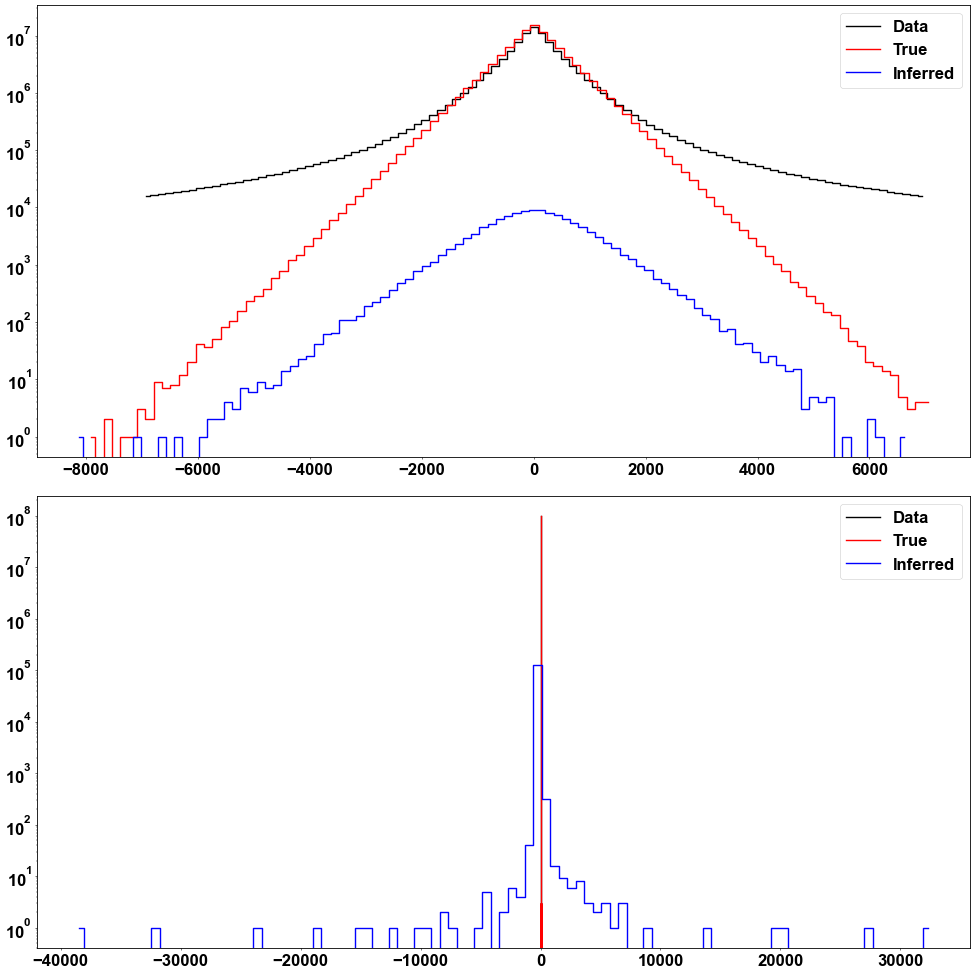

In [14]:
inferred_parallax = jft.mean_and_std(tuple(fwd(s) for s in samples))
inferred_dist = jft.mean_and_std(tuple(true_dist(s) for s in samples))

''' Plot Results'''
fig, axs = plt.subplots(2, 1, figsize=(20, 20))
n, bins = jnp.histogram(z_data, bins=101)
val = (bins[:-1] + bins[1:])/2
axs[0].plot(val, n, color='black', drawstyle='steps-mid', label='Data')
n, bins = jnp.histogram(z, bins=101)
val = (bins[:-1] + bins[1:])/2
axs[0].plot(val, n, color='red', drawstyle='steps-mid', label='True')
n, bins = jnp.histogram(inferred_dist[0], bins=101)
val = (bins[:-1] + bins[1:])/2
axs[0].plot(val, n, color='blue', drawstyle='steps-mid', label='Inferred')
axs[0].set_yscale('log')
n, bins = jnp.histogram(parallax_data, bins=101)
val = (bins[:-1] + bins[1:])/2
axs[1].plot(val, n, color='black', drawstyle='steps-mid', label='Data')
n, bins = jnp.histogram(parallax, bins=101)
val = (bins[:-1] + bins[1:])/2
axs[1].plot(val, n, color='red', drawstyle='steps-mid', label='True')
n, bins = jnp.histogram(inferred_parallax[0], bins=101)
val = (bins[:-1] + bins[1:])/2
axs[1].plot(val, n, color='blue', drawstyle='steps-mid', label='Inferred')
axs[1].set_yscale('log')
axs[0].legend()
axs[1].legend()
fig.tight_layout()
fig.set_dpi(50)
plt.show()